# **Project Objectives:**



*   Understand and clean real-world transportation data
*   Perform exploratory data analysis and visualization
*   Identify patterns and relationships in journey data
*   Build and evaluate a predictive machine learning model
*   Present insights in a structured and professional manner

In [3]:
#upload Dataset of yours

from google.colab import files
uploaded = files.upload()

Saving Dataset1.csv to Dataset1.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [5]:
df = pd.read_csv('/content/Dataset1.csv')

# **Level 1: Data Overview**

**Description:**
Develop a foundational understanding of the
dataset by examining its structure,
completeness, and basic statistics.

In [6]:
# first 5 rows

df.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [11]:
df.shape

(186074, 12)

In [9]:
df.columns

Index(['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL',
       'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time',
       'Distance'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   SN              186074 non-null  int64 
 1   Train_No        186074 non-null  int64 
 2   Station_Code    186074 non-null  object
 3   1A              186074 non-null  int64 
 4   2A              186074 non-null  int64 
 5   3A              186074 non-null  int64 
 6   SL              186074 non-null  int64 
 7   Station_Name    186074 non-null  object
 8   Route_Number    186074 non-null  int64 
 9   Arrival_time    186074 non-null  object
 10  Departure_Time  186074 non-null  object
 11  Distance        186074 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 17.0+ MB


**Train-Wise Table**


In [12]:
route_table = df.groupby('Train_No').agg({
    'Station_Name': ['first', 'last'],
    'Distance': 'max'
})

route_table.columns = ['Start_Station', 'End_Station', 'Total_Distance']

print(route_table.head())

         Start_Station   End_Station  Total_Distance
Train_No                                            
107       SAWANTWADI R   MADGOAN JN.              78
108        MADGOAN JN.  SAWANTWADI R              83
128        MADGOAN JN.   CHHATRAPATI             978
290       DELHI-SAFDAR  DELHI-SAFDAR            2694
401         AURANGABAD  VARANASI JN.            1618


**Basic Statistcs**

In [14]:
# Statistical summary

df.describe()

,SN,Train_No,1A,2A,3A,SL,Route_Number,Distance
count,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.0,186074.000000
mean,13.914695,42157.747455,1506.769189,1225.415351,944.061513,662.735777,1.0,281.353838
std,12.779368,25090.080221,2418.719821,1934.975856,1451.231892,967.524012,0.0,483.743964
min,1.000000,107.000000,100.000000,100.000000,100.000000,100.000000,1.0,0.000000
25%,5.000000,17225.000000,215.000000,192.000000,169.000000,146.000000,1.0,23.000000
50%,11.000000,40050.000000,465.000000,392.000000,319.000000,246.000000,1.0,73.000000
75%,18.000000,57550.000000,1555.000000,1264.000000,973.000000,682.000000,1.0,291.000000
max,118.000000,99908.000000,21400.000000,17140.000000,12880.000000,8620.000000,1.0,4260.000000


In [15]:
# Distance statistics

df['Distance'].describe()

,Distance
count,186074.000000
mean,281.353838
std,483.743964
min,0.000000
25%,23.000000
50%,73.000000
75%,291.000000
max,4260.000000


**Missing Values Analysis**

In [17]:
# Missing values

df.isnull().sum()

,0
SN,0
Train_No,0
Station_Code,0
1A,0
2A,0
3A,0
SL,0
Station_Name,0
Route_Number,0
Arrival_time,0


In [18]:
# Null value percentage

null_percent = (df.isnull().sum() / len(df)) * 100
null_percent

,0
SN,0.0
Train_No,0.0
Station_Code,0.0
1A,0.0
2A,0.0
3A,0.0
SL,0.0
Station_Name,0.0
Route_Number,0.0
Arrival_time,0.0


**LEVEL 1 CONCLUSION**

This level provided a complete overview of the dataset structure, column information, train route details, and missing values. Basic statistical analysis helped understand the distribution of train distances and dataset quality.

# **LEVEL 2: DATA CLEANING & FEATURE ENGINEERING**

**Objective**

Clean the dataset and create important features required for analysis and machine learning.

In [22]:
# Check duplicates

print(df.duplicated().sum())

0


In [26]:
# Remove duplicates

df.drop_duplicates(inplace=True)

# Fill missing values if required
numeric_columns = df.select_dtypes(include=np.number).columns
numeric_columns

Index(['SN', 'Train_No', '1A', '2A', '3A', 'SL', 'Route_Number', 'Distance'], dtype='object')

In [27]:
for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_5259/1651664703.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [29]:
# Convert time columns

df['Arrival_time'] = pd.to_datetime(
    df['Arrival_time'],
    errors='coerce'
)


df['Departure_Time'] = pd.to_datetime(
    df['Departure_Time'],
    errors='coerce'
)

# Check conversion
df[['Arrival_time', 'Departure_Time']].head()

,Arrival_time,Departure_Time
0,2026-05-26 00:00:00,2026-05-26 10:25:00
1,2026-05-26 11:06:00,2026-05-26 11:08:00
2,2026-05-26 11:28:00,2026-05-26 11:30:00
3,2026-05-26 12:10:00,2026-05-26 00:00:00
4,2026-05-26 00:00:00,2026-05-26 20:30:00


In [32]:
# Create journey duration

df['Journey_Duration'] = (
    df['Arrival_time'] - df['Departure_Time']
).dt.total_seconds() / 60

df['Journey_Duration'] = df['Journey_Duration'].abs()

# Check output
df['Journey_Duration'].head()

,Journey_Duration
0,625.0
1,2.0
2,2.0
3,730.0
4,1230.0


In [34]:
# Total stops
stops_per_train = df.groupby('Train_No')['Station_Code'].count()

df['Total_Stops'] = df['Train_No'].map(stops_per_train)

# Total route distance
route_distance = df.groupby('Train_No')['Distance'].max()


df['Total_Distance'] = df['Train_No'].map(route_distance)

# Check new features
df[['Total_Stops', 'Total_Distance']].head()

,Total_Stops,Total_Distance
0,4,78
1,4,78
2,4,78
3,4,78
4,4,83


**LEVEL 2 CONCLUSION**

This level focused on improving dataset quality through cleaning and preprocessing. Important features such as journey duration, total distance, and total stops were engineered successfully, making the dataset ready for exploratory analysis and machine learning.

# **LEVEL 3: DATA EXPLORATION**

**Objective**

Explore patterns and relationships within the dataset to gain meaningful insights.

In [36]:
# Average journey duration per train
journey_analysis = df.groupby('Train_No')['Journey_Duration'].mean().sort_values(ascending=False).head(10)

journey_analysis

,Journey_Duration
Train_No,
98886,1429.0
98780,1421.0
99107,1419.0
63168,1417.5
98887,1413.0
98884,1406.0
99502,1404.0
99041,1398.5
98783,1397.0


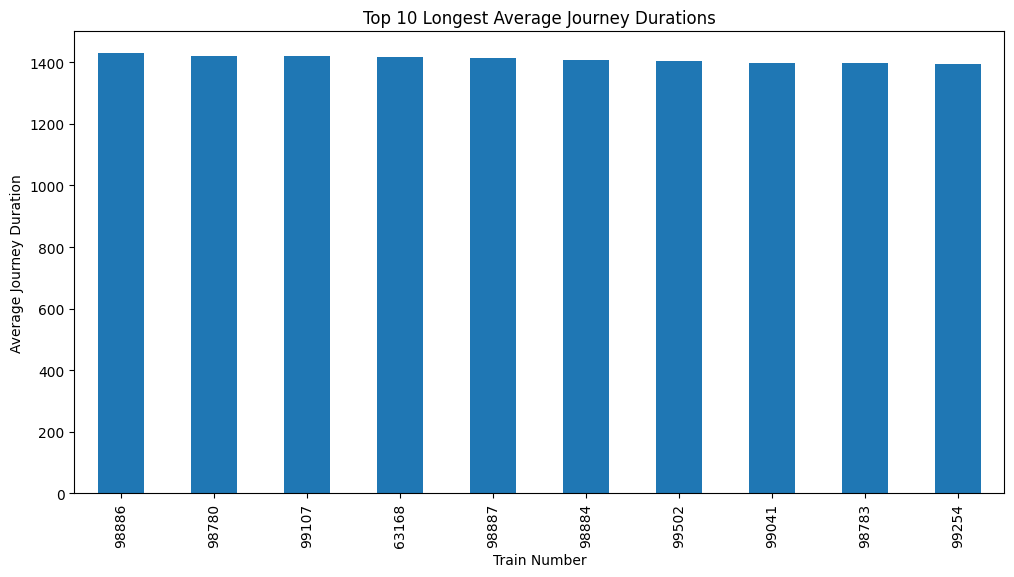

In [37]:
journey_analysis.plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Longest Average Journey Durations')
plt.xlabel('Train Number')
plt.ylabel('Average Journey Duration')
plt.show()

In [38]:
# Station traffic analysis
station_traffic = df['Station_Name'].value_counts()
station_traffic.head(10)

,count
Station_Name,
CST-MUMBAI,1027
KALYAN JN,828
THANE,796
SEALDAH,745
CHENNAI BEAC,738
HOWRAH JN.,699
DADAR,598
DUM DUM JN.,463
KURLA,462


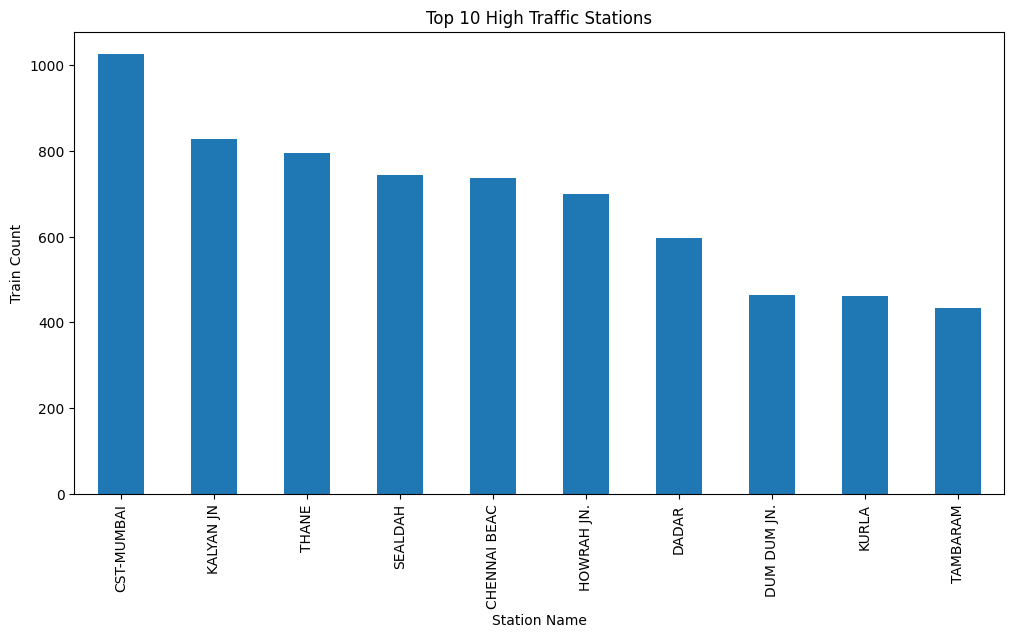

In [39]:
station_traffic.head(10).plot(kind='bar', figsize=(12,6))
plt.title('Top 10 High Traffic Stations')
plt.xlabel('Station Name')
plt.ylabel('Train Count')
plt.show()

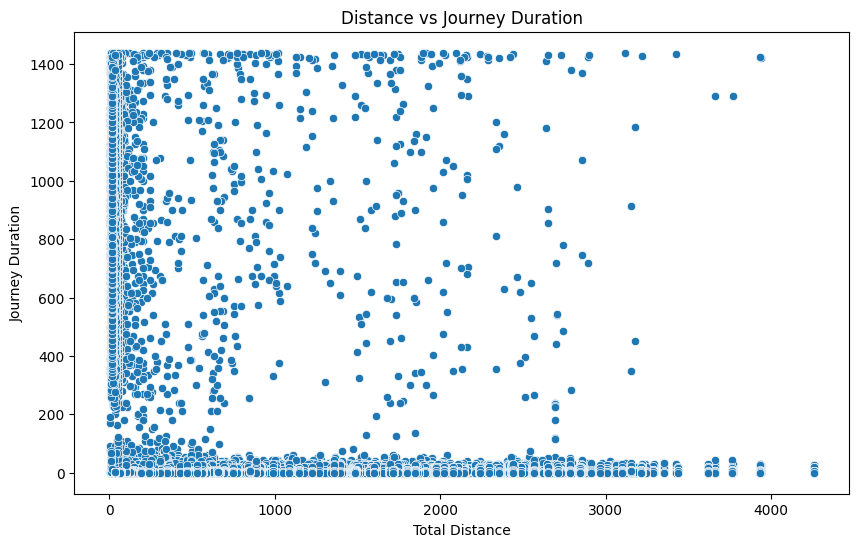

In [40]:
plt.figure(figsize=(10,6))
sns.scatterplot( x=df['Total_Distance'], y=df['Journey_Duration'])
plt.title('Distance vs Journey Duration')
plt.xlabel('Total Distance')
plt.ylabel('Journey Duration')
plt.show()

**Insights**

* Long-distance trains generally require higher journey durations.
* Some stations experience significantly higher train traffic.
* Journey duration shows a positive relationship with total distance.
* Route characteristics strongly influence train timings.







# **LEVEL 4: VISUALIZATION & PATTERN ANALYSIS**

**Objective**

Use visual tools to identify trends, patterns, and relationships in the data.

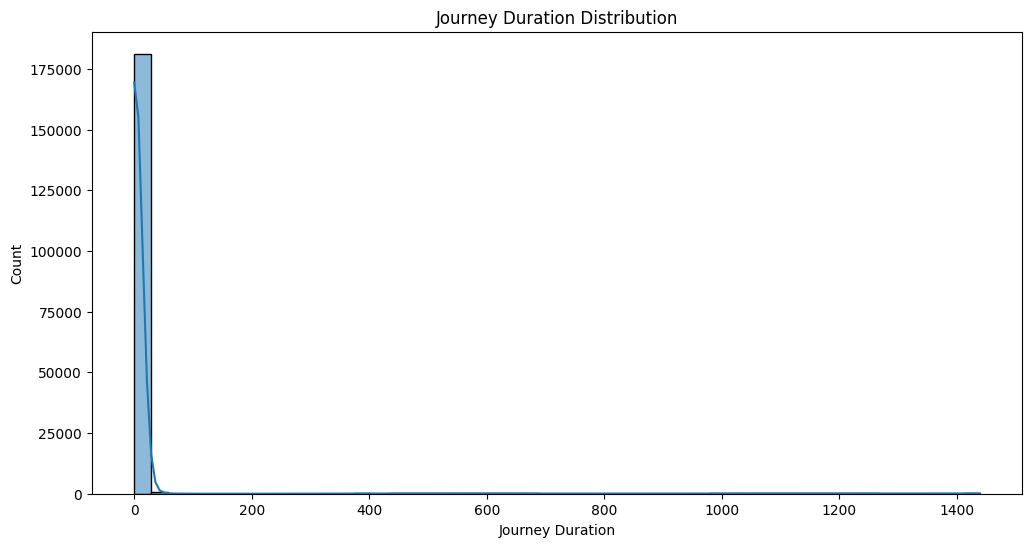

In [41]:
plt.figure(figsize=(12,6))
sns.histplot(df['Journey_Duration'], bins=50, kde=True)
plt.title('Journey Duration Distribution')
plt.xlabel('Journey Duration')
plt.show()

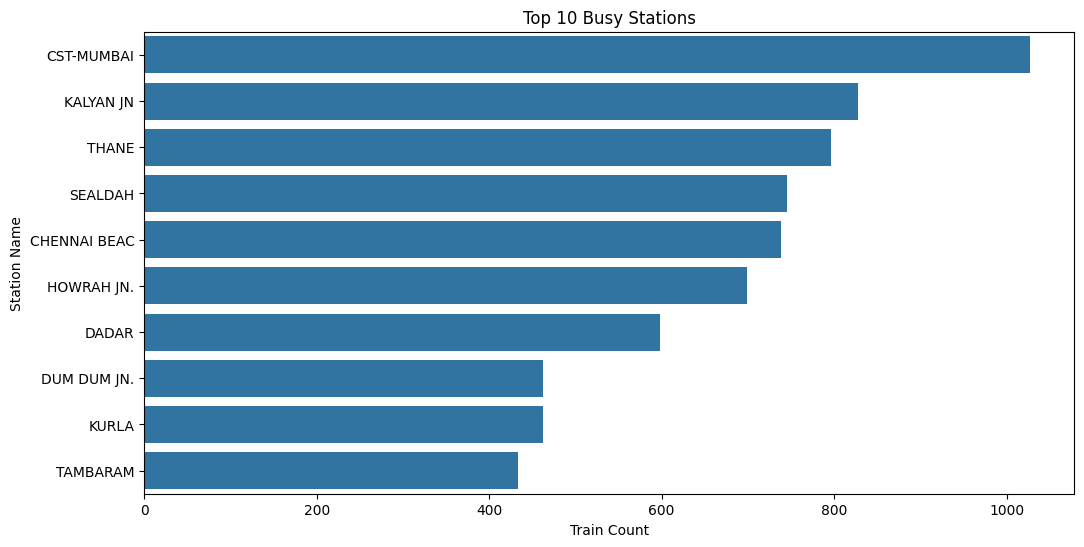

In [42]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=station_traffic.head(10).values,
    y=station_traffic.head(10).index
)
plt.title('Top 10 Busy Stations')
plt.xlabel('Train Count')
plt.ylabel('Station Name')
plt.show()

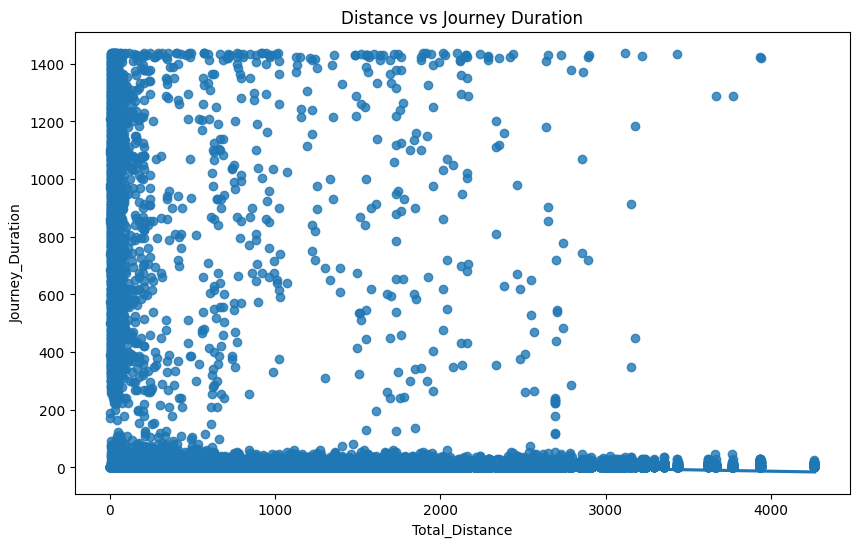

In [43]:
plt.figure(figsize=(10,6))
sns.regplot(
    x=df['Total_Distance'],
    y=df['Journey_Duration']
)
plt.title('Distance vs Journey Duration')
plt.show()

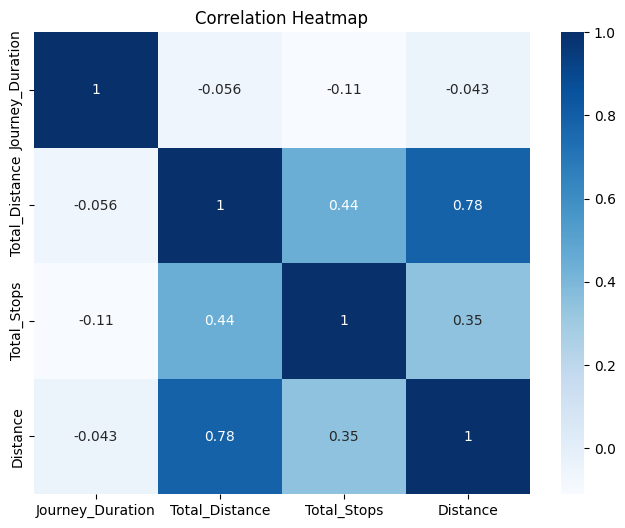

In [44]:
# Correlation matrix
corr = df[['Journey_Duration', 'Total_Distance', 'Total_Stops', 'Distance']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

**LEVEL 4 CONCLUSION**

Visual analysis helped identify strong relationships between important variables. The visualizations improved understanding of train behavior, traffic distribution, and journey patterns.

# **LEVEL 5: PREDICTION MODEL DEVELOPMENT**

**Objective**
Build and evaluate a machine learning model capable of predicting train journey duration.

In [47]:
# Prepare Modelling Dataset

X = df[['Total_Distance', 'Total_Stops']]

y = df['Journey_Duration']

model_data = pd.concat([X, y], axis=1).dropna()

X = model_data[['Total_Distance', 'Total_Stops']]
y = model_data['Journey_Duration']

In [48]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
# Build Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [53]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error (MAE):', mae)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('\nRoot Mean Squared Error (RMSE)', rmse)


r2 = r2_score(y_test, y_pred)
print('\nR2 Score:', r2)

Mean Absolute Error (MAE): 39.36992980330915

Root Mean Squared Error (RMSE) 134.91450910469862

R2 Score: 0.012021234037654094


**LEVEL 5 CONCLUSION**

A Linear Regression model was successfully developed to predict train journey duration using distance and total stops as features. The model was evaluated using MAE, RMSE, and R2 score.

# **Level 6: Final Data Science Project**

**Description:**
Integrate analysis and modeling into a complete
prediction system with visualization.

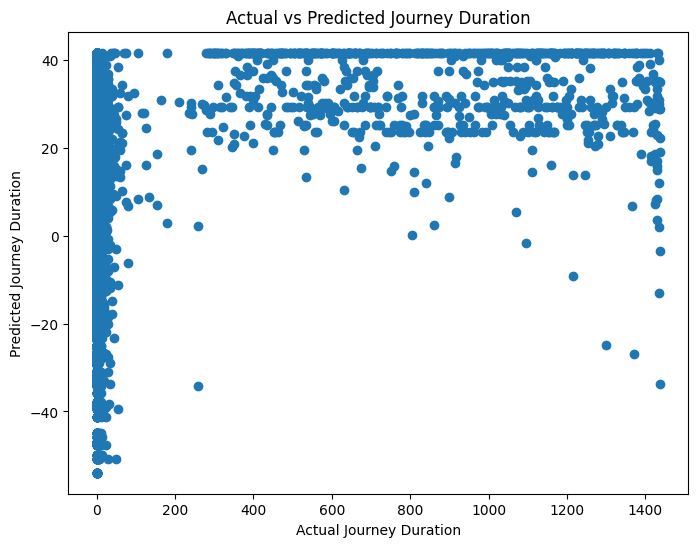

In [55]:
#Visualize Actual vs Prdeicted Values

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Journey Duration')
plt.ylabel('Predicted Journey Duration')

plt.title('Actual vs Predicted Journey Duration')

plt.show()

# **Skill Gained**

* Technical Skills
* Python Programming
* Data Analysis
* Data Cleaning
* Feature Engineering
* EDA
* Data Visualization
* Machine Learning
* Model Evaluation
* Statistical Analysis

# **Tools Learned**

*   Google Colab
*   Pandas
*   NumPy
*   Matplotlib
*   Seaborn
*   Scikit-learn
*   GitHub











# **Description**

Completed an end-to-end Data Science project on Train Route Analysis and Journey Time Prediction using Python, Pandas, Visualization, and Machine Learning. The project included data preprocessing, exploratory analysis, feature engineering, visualization, and Linear Regression model development.

